# Лабораторна робота №4: Візуалізація даних 2 (Інтерактивна гармоніка)

### Інструкція користувача:
1. **Слайдери:** Перетягуйте повзунки (Amplitude, Frequency, Phase), щоб змінювати форму "чистої" гармоніки.
2. **Параметри шуму:** Використовуйте `Noise Mean` та `Noise Covariance` для зміни характеристик завад. Згідно з вимогами, базовий патерн шуму є фіксованим, тому при зміні параметрів гармоніки шум не перемальовується хаотично.
3. **Фільтрація:** Слайдер `Cutoff Frequency` керує частотою зрізу ФНЧ (фільтра Баттерворта). Чим менше значення, тим сильніше згладжується графік.
4. **Керування відображенням:** Використовуйте чекбокс `Show Noise`, щоб сховати або показати жовтий зашумлений сигнал.
5. **Скидання:** Натисніть кнопку `Reset`, щоб повернути всі повзунки до початкових значень.

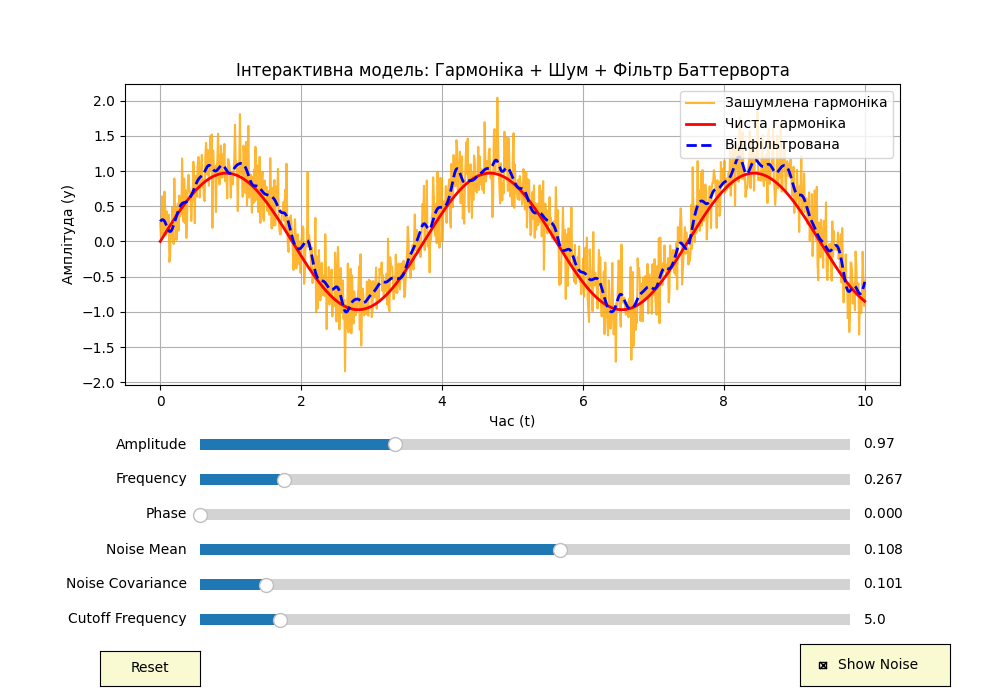

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

t = np.linspace(0, 10, 1000)
A_init = 0.97
f_init = 0.267
phi_init = 0.0
n_mean_init = 0.108
n_cov_init = 0.101
cutoff_init = 5.0

np.random.seed(42)
base_noise = np.random.normal(0, 1, len(t))

def get_harmonic(A, f, phi):
    return A * np.sin(2 * np.pi * f * t + phi)

def get_noise(mean, cov):
    std_dev = np.sqrt(max(cov, 0.0001))
    return base_noise * std_dev + mean

def filter_signal(data, cutoff, fs=100.0):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(3, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

y_clean = get_harmonic(A_init, f_init, phi_init)
y_noise = get_noise(n_mean_init, n_cov_init)
y_noisy = y_clean + y_noise
y_filtered = filter_signal(y_noisy, cutoff_init)

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.45)

line_noisy, = ax.plot(t, y_noisy, color='orange', alpha=0.8, label='Зашумлена гармоніка')
line_clean, = ax.plot(t, y_clean, color='red', linewidth=2, label='Чиста гармоніка')
line_filtered, = ax.plot(t, y_filtered, color='blue', linestyle='--', linewidth=2, label='Відфільтрована')

ax.set_title("Інтерактивна модель: Гармоніка + Шум + Фільтр Баттерворта")
ax.set_xlabel("Час (t)")
ax.set_ylabel("Амплітуда (y)")
ax.legend(loc='upper right')
ax.grid(True)

axcolor = 'lightgoldenrodyellow'
ax_A = plt.axes([0.2, 0.35, 0.65, 0.03], facecolor=axcolor)
ax_f = plt.axes([0.2, 0.30, 0.65, 0.03], facecolor=axcolor)
ax_phi = plt.axes([0.2, 0.25, 0.65, 0.03], facecolor=axcolor)
ax_n_mean = plt.axes([0.2, 0.20, 0.65, 0.03], facecolor=axcolor)
ax_n_cov = plt.axes([0.2, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_cutoff = plt.axes([0.2, 0.10, 0.65, 0.03], facecolor=axcolor)

s_A = Slider(ax_A, 'Amplitude', 0.1, 3.0, valinit=A_init)
s_f = Slider(ax_f, 'Frequency', 0.01, 2.0, valinit=f_init)
s_phi = Slider(ax_phi, 'Phase', 0.0, 2*np.pi, valinit=phi_init)
s_n_mean = Slider(ax_n_mean, 'Noise Mean', -1.0, 1.0, valinit=n_mean_init)
s_n_cov = Slider(ax_n_cov, 'Noise Covariance', 0.0, 1.0, valinit=n_cov_init)
s_cutoff = Slider(ax_cutoff, 'Cutoff Frequency', 0.1, 40.0, valinit=cutoff_init)

ax_check = plt.axes([0.8, 0.02, 0.15, 0.06], facecolor=axcolor)
check = CheckButtons(ax_check, ['Show Noise'], [True])

ax_reset = plt.axes([0.1, 0.02, 0.1, 0.05])
btn_reset = Button(ax_reset, 'Reset', color=axcolor, hovercolor='0.975')

def update(val):
    A = s_A.val
    f = s_f.val
    phi = s_phi.val
    n_mean = s_n_mean.val
    n_cov = s_n_cov.val
    cutoff = s_cutoff.val
    
    new_clean = get_harmonic(A, f, phi)
    new_noise = get_noise(n_mean, n_cov)
    new_noisy = new_clean + new_noise
    new_filtered = filter_signal(new_noisy, cutoff)
    
    line_clean.set_ydata(new_clean)
    line_noisy.set_ydata(new_noisy)
    line_filtered.set_ydata(new_filtered)
    
    fig.canvas.draw_idle()

s_A.on_changed(update)
s_f.on_changed(update)
s_phi.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_cutoff.on_changed(update)

def toggle_noise(label):
    line_noisy.set_visible(check.get_status()[0])
    fig.canvas.draw_idle()

check.on_clicked(toggle_noise)

def reset(event):
    s_A.reset()
    s_f.reset()
    s_phi.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_cutoff.reset()

btn_reset.on_clicked(reset)

plt.show()